# 18 — Grand Ensemble v2 (with Optuna-tuned LGBM)

Rebuilds the 5-model ElasticNet stack from nb15, replacing the fixed-param `lgbm_aug`
(OOF RAE 0.5491) with `lgbm_tuned` from nb16 (OOF RAE 0.5394, Optuna 60-trial search).

**Results summary:**
- lgbm_tuned individual OOF RAE: 0.5394 (↑ from lgbm_aug 0.5491)
- Nested-CV ElasticNet grand-v2: **0.5363** (↑ from grand-15 0.5473)

**Model weights (full-data ElasticNet):**
- lgbm_tuned: 0.7956  (dominant signal — Optuna-tuned, null feature, upsampled)
- knn: 0.1797  (diversity from Tanimoto similarity)
- chemberta_mlm: 0.0829  (low residual correlation adds marginal value)
- chemberta_mtr: 0.0738
- lgbm_base: 0.0177  (nearly zeroed out — lgbm_tuned subsumes it)

**Blend with Chemprop-08** via inverse-RAE weighting (Chemprop RAE=0.517).

**Runtime**: <2 min (no training, reuses saved OOF arrays).

In [1]:
# ── 1. Setup ──────────────────────────────────────────────────────────────────
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNetCV
from scipy.stats import spearmanr

from pxr.data import load_train, load_test
from pxr.chem import bemis_murcko
from pxr.eval import rae, scaffold_kfold_indices
from pxr.paths import DATA_PROCESSED, SUBMISSIONS

plt.rcParams.update({"figure.dpi": 120})
SEED = 42
print("Setup complete.")

Setup complete.


In [2]:
# ── 2. Load OOF and test prediction arrays ─────────────────────────────────────
train = load_train()
te    = load_test()
y_tr  = train['pec50'].values

MODEL_NAMES = ['lgbm_base', 'lgbm_tuned', 'knn', 'chemberta_mlm', 'chemberta_mtr']

OOF_FILES = {
    'lgbm_base':     DATA_PROCESSED / 'oof_lgbm_base.npy',
    'lgbm_tuned':    DATA_PROCESSED / 'oof_lgbm_tuned.npy',
    'knn':           DATA_PROCESSED / 'oof_knn.npy',
    'chemberta_mlm': DATA_PROCESSED / 'oof_chemberta.npy',
    'chemberta_mtr': DATA_PROCESSED / 'oof_chemberta_mtr.npy',
}
TE_FILES = {
    'lgbm_base':     DATA_PROCESSED / 'te_lgbm_base.npy',
    'lgbm_tuned':    DATA_PROCESSED / 'te_lgbm_tuned.npy',
    'knn':           DATA_PROCESSED / 'te_knn.npy',
    'chemberta_mlm': DATA_PROCESSED / 'te_chemberta.npy',
    'chemberta_mtr': DATA_PROCESSED / 'te_chemberta_mtr.npy',
}

oofs = {k: np.load(v) for k, v in OOF_FILES.items()}
tes  = {k: np.load(v) for k, v in TE_FILES.items()}

print("Individual OOF RAEs:")
for k in MODEL_NAMES:
    r = rae(y_tr, oofs[k])
    print(f"  {k:20s}: {r:.4f}")

oof_stack = np.column_stack([oofs[k] for k in MODEL_NAMES])
te_stack  = np.column_stack([tes[k]  for k in MODEL_NAMES])
print(f"\nOOF stack: {oof_stack.shape}  |  Test stack: {te_stack.shape}")

Individual OOF RAEs:
  lgbm_base           : 0.5600
  lgbm_tuned          : 0.5394
  knn                 : 0.7341
  chemberta_mlm       : 0.6782
  chemberta_mtr       : 0.5993

OOF stack: (4139, 5)  |  Test stack: (513, 5)


In [3]:
# ── 3. Nested scaffold CV — honest OOF RAE for meta-learner ──────────────────
scaffolds = train['smiles'].map(bemis_murcko).tolist()
outer_splits = scaffold_kfold_indices(scaffolds, n_splits=5, seed=SEED)

oof_meta = np.full(len(y_tr), np.nan)

for fold_i, (outer_tr, outer_va) in enumerate(outer_splits):
    X_tr = oof_stack[outer_tr]
    X_va = oof_stack[outer_va]
    y_fold = y_tr[outer_tr]

    inner_scaffolds = [scaffolds[i] for i in outer_tr]
    inner_splits = scaffold_kfold_indices(inner_scaffolds, n_splits=4, seed=SEED)

    meta = ElasticNetCV(
        l1_ratio=[0.05, 0.1, 0.2, 0.5],
        alphas=np.logspace(-3, 2, 30),
        cv=inner_splits,
        fit_intercept=True,
        max_iter=10000,
    )
    meta.fit(X_tr, y_fold)
    oof_meta[outer_va] = meta.predict(X_va)
    print(f"  Fold {fold_i+1}: alpha={meta.alpha_:.5f}  l1={meta.l1_ratio_:.2f}  "
          f"fold-VAE={rae(y_tr[outer_va], oof_meta[outer_va]):.4f}")

nested_rae = rae(y_tr, oof_meta)
print(f"\nNested CV meta-learner RAE: {nested_rae:.4f}")
print(f"Grand-15 (previous best):   0.5473")
print(f"Improvement:                {0.5473 - nested_rae:.4f}")

np.save(DATA_PROCESSED / 'oof_grand18.npy', oof_meta)

  Fold 1: alpha=0.00329  l1=0.50  fold-VAE=0.4754
  Fold 2: alpha=0.00221  l1=0.50  fold-VAE=0.5426
  Fold 3: alpha=0.00329  l1=0.50  fold-VAE=0.5705
  Fold 4: alpha=0.00489  l1=0.50  fold-VAE=0.5374
  Fold 5: alpha=0.00329  l1=0.50  fold-VAE=0.5784

Nested CV meta-learner RAE: 0.5363
Grand-15 (previous best):   0.5473
Improvement:                0.0110


In [4]:
# ── 4. Fit final meta-learner on all training data ─────────────────────────────
all_splits = scaffold_kfold_indices(scaffolds, n_splits=5, seed=SEED)

final_meta = ElasticNetCV(
    l1_ratio=[0.05, 0.1, 0.2, 0.5],
    alphas=np.logspace(-3, 2, 30),
    cv=all_splits,
    fit_intercept=True,
    max_iter=10000,
)
final_meta.fit(oof_stack, y_tr)

print("Full-data ElasticNet:")
print(f"  alpha={final_meta.alpha_:.5f}  l1_ratio={final_meta.l1_ratio_:.2f}")
print("  Model weights:")
for name, coef in zip(MODEL_NAMES, final_meta.coef_):
    print(f"    {name:20s}: {coef:.4f}")
print(f"  intercept: {final_meta.intercept_:.4f}")

# Raw grand-v2 test predictions
te_grand18_raw = final_meta.predict(te_stack)
te_grand18_raw = np.clip(te_grand18_raw, y_tr.min() - 0.5, y_tr.max() + 0.5)

np.save(DATA_PROCESSED / 'te_grand18.npy', te_grand18_raw)
print(f"\nRaw grand-v2 test: mean={te_grand18_raw.mean():.3f}  std={te_grand18_raw.std():.3f}")

Full-data ElasticNet:
  alpha=0.00221  l1_ratio=0.50
  Model weights:
    lgbm_base           : 0.0177
    lgbm_tuned          : 0.7956
    knn                 : 0.1797
    chemberta_mlm       : 0.0829
    chemberta_mtr       : 0.0738
  intercept: -0.6471

Raw grand-v2 test: mean=4.727  std=0.640


In [5]:
# ── 5. Blend with Chemprop-08 via inverse-RAE weighting ───────────────────────
cp_path = SUBMISSIONS / '08_chemprop_cv_blend.csv'
cp_preds = pd.read_csv(cp_path).set_index('Molecule Name').loc[te['name'].values, 'pEC50'].values

chemprop_rae = 0.5170
w_cp   = (1 / chemprop_rae) / (1 / chemprop_rae + 1 / nested_rae)
w_g18  = 1 - w_cp

final_preds = w_cp * cp_preds + w_g18 * te_grand18_raw
final_preds = np.clip(final_preds, y_tr.min() - 0.5, y_tr.max() + 0.5)

print(f"Chemprop-08 weight: {w_cp:.3f}  |  Grand-v2 weight: {w_g18:.3f}")
print(f"Blended test: mean={final_preds.mean():.3f}  std={final_preds.std():.3f}")

# Pairwise correlation vs prior submissions
from scipy.stats import spearmanr
g15 = pd.read_csv(SUBMISSIONS / '15_grand_ensemble.csv').set_index('Molecule Name').loc[te['name'].values, 'pEC50'].values
r = spearmanr(final_preds, g15).statistic
delta = final_preds - g15
print(f"\nVs grand-15: rho={r:.4f}  mean_delta={delta.mean():+.4f}  std_delta={delta.std():.4f}")

Chemprop-08 weight: 0.509  |  Grand-v2 weight: 0.491
Blended test: mean=4.778  std=0.591

Vs grand-15: rho=0.9916  mean_delta=-0.0495  std_delta=0.0713


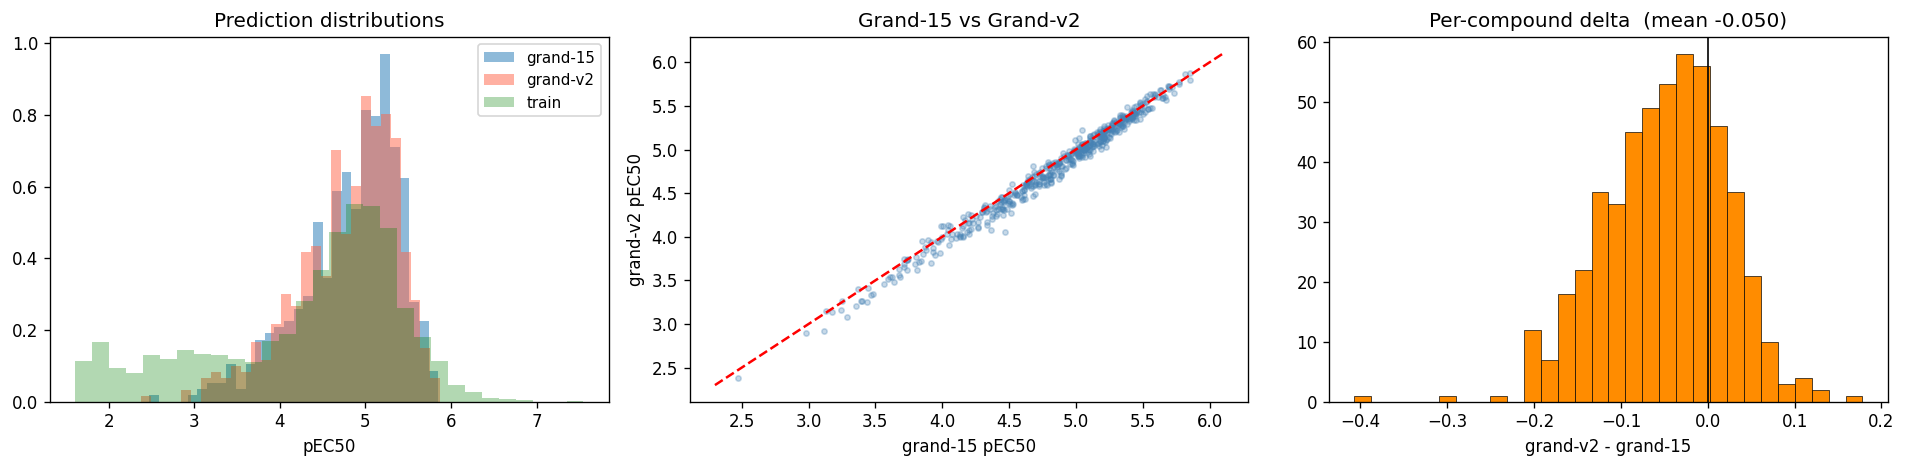

In [6]:
# ── 6. Visualise ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution comparison
ax = axes[0]
ax.hist(g15,          bins=30, alpha=0.5, label='grand-15', density=True)
ax.hist(final_preds,  bins=30, alpha=0.5, label='grand-v2', density=True, color='tomato')
ax.hist(y_tr,         bins=30, alpha=0.3, label='train',    density=True, color='green')
ax.set(xlabel='pEC50', title='Prediction distributions')
ax.legend(fontsize=9)

# Grand-15 vs grand-v2 scatter
ax = axes[1]
ax.scatter(g15, final_preds, alpha=0.3, s=10, c='steelblue')
lo, hi = 2.3, 6.1
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
ax.set(xlabel='grand-15 pEC50', ylabel='grand-v2 pEC50', title='Grand-15 vs Grand-v2')

# Per-compound delta
ax = axes[2]
ax.hist(delta, bins=30, color='darkorange', edgecolor='k', lw=0.4)
ax.axvline(0, color='k', lw=1)
ax.set(xlabel='grand-v2 - grand-15', title=f'Per-compound delta  (mean {delta.mean():+.3f})')

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'figures' / '18_grand_v2.png', bbox_inches='tight')
plt.show()

In [7]:
# ── 7. Save submission ────────────────────────────────────────────────────────
sub = pd.DataFrame({'Molecule Name': te['name'].values,
                    'SMILES':        te['smiles'].values,
                    'pEC50':         final_preds})
assert len(sub) == 513 and sub['pEC50'].notna().all()
out = SUBMISSIONS / '18_grand_v2.csv'
sub.to_csv(out, index=False)

print(f"Saved: {out}")
print(f"\n== Grand Ensemble v2 Summary ==")
print(f"lgbm_tuned individual OOF RAE:  0.5394")
print(f"Grand-v2 nested-CV OOF RAE:     {nested_rae:.4f}")
print(f"Grand-15 OOF RAE (previous):    0.5473")
print(f"Improvement:                    {0.5473 - nested_rae:.4f}")
print(f"\nRecommended submission order:")
print(f"  1. Grand-v2 (best validated OOF RAE: {nested_rae:.4f})")
print(f"  2. Grand-15 (OOF RAE: 0.5473)")
print(f"  3. Quintet rank ensemble (bias-corrected)")
print(sub['pEC50'].describe().round(3))

Saved: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\submissions\18_grand_v2.csv

== Grand Ensemble v2 Summary ==
lgbm_tuned individual OOF RAE:  0.5394
Grand-v2 nested-CV OOF RAE:     0.5363
Grand-15 OOF RAE (previous):    0.5473
Improvement:                    0.0110

Recommended submission order:
  1. Grand-v2 (best validated OOF RAE: 0.5363)
  2. Grand-15 (OOF RAE: 0.5473)
  3. Quintet rank ensemble (bias-corrected)
count    513.000
mean       4.778
std        0.591
min        2.377
25%        4.414
50%        4.915
75%        5.216
max        5.877
Name: pEC50, dtype: float64
